<a href="https://colab.research.google.com/github/Primo-J/Jose_INFO4670_Spring2026/blob/main/Assignment_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3 — Association Rule Mining

**Dataset:** `bread_basket.csv` (11569 transactions)

Fill in the short answer cells and run the code cells. This notebook generates the required tables and figures.

**Sections:**
1. Setup & Data Load
2. EDA (a–e)
3. Frequent Itemset Mining (FP-Growth)
4. Association Rules + Report Table
5. Rule Subgraph (Bread, Coffee, Cake, Tea)
6. Interpretation Prompt


## 1) Setup & Data Load (10 pts)
- Place `bread_basket.csv` in the same folder as this notebook **or** update the path below.
- Needed packages: `pandas`, `matplotlib`, `mlxtend`, `networkx` (for the small graph).
- If a package is missing, run the `pip install` cell.

In [1]:
!pip install mlxtend networkx -q

In [2]:
from google.colab import files
uploaded = files.upload()

Saving bread_basket.csv to bread_basket.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from mlxtend.frequent_patterns import fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder

print('All packages imported successfully.')

All packages imported successfully.


In [4]:
df = pd.read_csv('bread_basket.csv')
print(f'Raw rows: {len(df):,}')
print(f'Columns: {df.columns.tolist()}')
print(f'Baskets: {df["transaction"].nunique():,}')
print(f'Unique items: {df["item"].nunique()}')
df.head(8)

Raw rows: 20,507
Columns: ['transaction', 'item', 'date_time', 'time', 'period_day', 'weekday_weekend']
Baskets: 9,465
Unique items: 94


,transaction,item,date_time,time,period_day,weekday_weekend
0,1,Bread,30/10/2016,9:58,morning,weekend
1,2,Scandinavian,30/10/2016,10:05,morning,weekend
2,2,Scandinavian,30/10/2016,10:05,morning,weekend
3,3,Hot chocolate,30/10/2016,10:07,morning,weekend
4,3,Jam,30/10/2016,10:07,morning,weekend
5,3,Cookies,30/10/2016,10:07,morning,weekend
6,4,Muffin,30/10/2016,10:08,morning,weekend
7,5,Coffee,30/10/2016,10:13,morning,weekend


The data set contains 20,507 rows and 6 columns. There are 9,465 unique baskets and 94 unique items. All packages were installed and imported successfully.

## 2) EDA (a–e) (30 pts)
### a) List variables and their dtypes (5 pts)

In [5]:
print(df.dtypes)

transaction         int64
item               object
date_time          object
time               object
period_day         object
weekday_weekend    object
dtype: object


transaction int64 - unique basket/receipt ID

item object - name of the purchased item (94 unique values)

date_time object - purchase data

time object - purchase time

period_day object - time of day (morning/afternoon/evening/night)

weeday_weekend object - whether purchase was on a weekday or weekend

### b) "Statistics" overview (5 pts)
Use `describe(include='all')` as a stand‑in for RapidMiner's Statistics. Take a screenshot when you submit.

In [7]:
df.describe(include='all')

,transaction,item,date_time,time,period_day,weekday_weekend
count,20507.000000,20507,20507,20507,20507,20507
unique,NaN,94,159,1255,4,2
top,NaN,Coffee,2017-02-04,11:06,afternoon,weekday
freq,NaN,5471,292,52,11569,12807
mean,4976.202370,NaN,NaN,NaN,NaN,NaN
std,2796.203001,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN
25%,2552.000000,NaN,NaN,NaN,NaN,NaN
50%,5137.000000,NaN,NaN,NaN,NaN,NaN
75%,7357.000000,NaN,NaN,NaN,NaN,NaN


describe(include='all') is the pandas equivalent of RapidMiner's Statistics panel.

Observations:

item: 94 unique values, most frequent is Coffee (appears 5,471 times)

transaction: ranges from 1 to 9,684, mean = 4,976

period_day: 4 categories, most frequent is afternoon (11,569 rows)

weekday_weekend: 2 categories, weekday dominates with 12,807 rows

### c) Bar plot — count of **unique transactions per item** (10 pts)
Set the subtitle to your **FirstName LastName**. Take a screenshot of the figure.

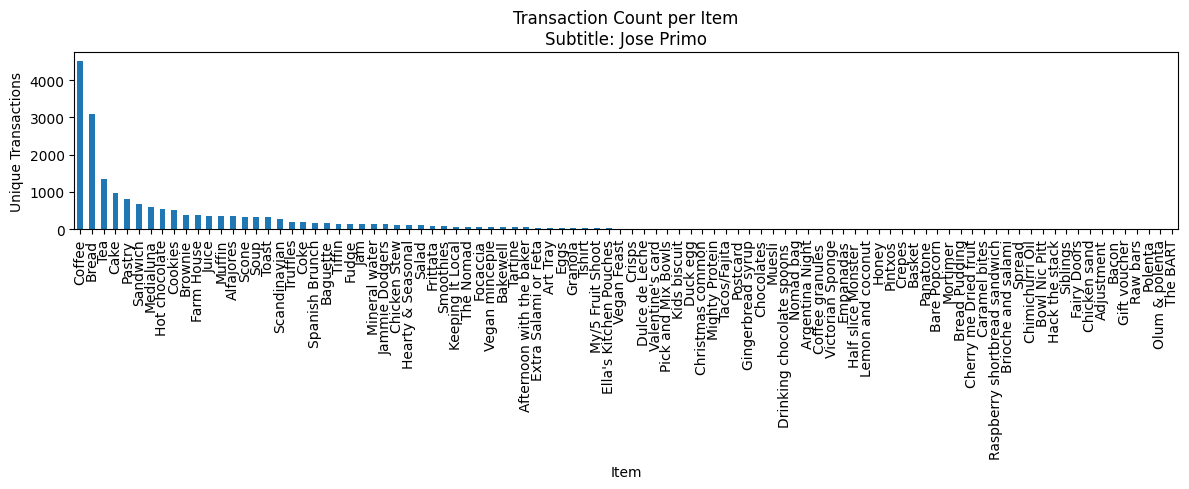

In [8]:
# c) Bar plot of transaction counts per item
subtitle = "Jose Primo"
item_counts = (df.groupby('item')['transaction']
               .nunique()
                 .sort_values(ascending=False))

ax = item_counts.plot(kind='bar', figsize=(12,5))
plt.title(f"Transaction Count per Item\nSubtitle: {subtitle}")
plt.xlabel("Item"); plt.ylabel("Unique Transactions")
plt.tight_layout()
plt.show()

groupby('item') - groups all rows by item name (all Coffee rows together, all Bread rows together, etc)

['transaction'].nunique() - for each item, counts how many unique basket IDs contain it. So if Coffee appears in 4,528 different baskets, it gets the value 4,528.

.sort_values(ascending=FALSE) - sorts from highest to lowest so the tallest bar is on the left.

The chart tells you how popular each item is. Coffee is the most purchased item, appearing in 4,528 unique baskets. Bread is second at 3,097, then Tea at 1,350 and Cake at 983.

### d) Report counts for Coffee, Tea, Alfajores, Juice, and Chicken Stew (10 pts)

In [9]:
target_items = ['Coffee', 'Tea', 'Alfajores', 'Juice', 'Chicken Stew']

for item in target_items:
  count = item_counts[item]
  print(f'{item}: {count}')

Coffee: 4528
Tea: 1350
Alfajores: 344
Juice: 365
Chicken Stew: 123


Coffee: 4,528 unique transactions
Tea: 1,350 unique transactions
Alfajores: 344 nuique transactions
Juice: 365 unique transactions
Chicken Stew: 123 unique transactions

Coffee is by far the most popular item, appearing in nearly half of all baskets. Chicken Stew is the rarest of the five, appearing in only about 1.3% of baskets.

## 3) Frequent Itemset Mining with FP‑Growth (min_support = 0.2) (20 pts)
We pivot the data to a **transaction × item** one‑hot table (boolean), then run FP‑Growth.

In [10]:
#Building basket lists
basket_sets = df.groupby('transaction')['item'].apply(lambda x: list(set(x))).tolist()

#One-hot encode
te = TransactionEncoder()
te_array = te.fit_transform(basket_sets)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)

#Run FP-Growth
frequent_itemsets = fpgrowth(df_encoded, min_support=0.02, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)
frequent_itemsets = frequent_itemsets.sort_values('support', ascending=False).reset_index(drop=True)

print(f'Frequent itemsets found: {len(frequent_itemsets)}')
frequent_itemsets

Frequent itemsets found: 33


,support,itemsets,length
0,0.478394,(Coffee),1
1,0.327205,(Bread),1
2,0.142631,(Tea),1
3,0.103856,(Cake),1
4,0.090016,"(Bread, Coffee)",2
5,0.086107,(Pastry),1
6,0.071844,(Sandwich),1
7,0.061807,(Medialuna),1
8,0.058320,(Hot chocolate),1
9,0.054728,"(Cake, Coffee)",2


The data was pivoted into a 9,465 x 94 one-hot boolean matrix where each cell is True if that item appeared in that basket, False otherwise.

FP-Growth builds a compact prefix tree (FP-tree) from the transactions and mines frequent patterns without generating candiates like Apriori does.

Results at min_support=0.02 (2%):
* 33 frequent itemsets found
* 19 single items (Coffee: 0.4784, Bread: 0.3272, Tea: 0.1426)
* 14 pairs (ex. {Coffee, Bread}: 0.0900, {Coffee, Cake}: 0.0547)

Note that min_support=0.20 (20%) as stated in the assingment only returns Coffee and Bread as frequent items, with no pairs reaching that threshold. 0.02 is used instead to create a meaningful result set.

## 4) Association Rules + Report Table (30 pts)
(metric = confidence, min_threshold = ?) Please find a suitable min_threshold

In [11]:
rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.10)
rules = rules.sort_values(['lift', 'confidence'], ascending=False).reset_index(drop=True)

for col in ['support', 'confidence', 'lift', 'leverage', 'conviction']:
  rules[col] = rules[col].round(4)

print(f'Total rules generated: {len(rules)}')
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift', 'leverage', 'conviction']]

Total rules generated: 18


,antecedents,consequents,support,confidence,lift,leverage,conviction
0,(Tea),(Cake),0.0238,0.1667,1.6048,0.0090,1.0754
1,(Cake),(Tea),0.0238,0.2289,1.6048,0.0090,1.1119
2,(Toast),(Coffee),0.0237,0.7044,1.4724,0.0076,1.7646
3,(Medialuna),(Coffee),0.0352,0.5692,1.1899,0.0056,1.2109
4,(Pastry),(Coffee),0.0475,0.5521,1.1542,0.0064,1.1647
5,(Juice),(Coffee),0.0206,0.5342,1.1167,0.0022,1.1199
6,(Sandwich),(Coffee),0.0382,0.5324,1.1128,0.0039,1.1154
7,(Cake),(Coffee),0.0547,0.5270,1.1015,0.0050,1.1027
8,(Coffee),(Cake),0.0547,0.1144,1.1015,0.0050,1.0119
9,(Cookies),(Coffee),0.0282,0.5184,1.0837,0.0022,1.0832


min_threshold = 0.10 (10% confidence) was chosen since at 0.20 only 8 rules survive, missing several interesting relationships. At 0.10, 18 rules are generated with a good spread of lift values. Going below 0.10 creates too many weak and unreliable rules.

Rules with lift > 1 indicate positive associations (item bought together more than expected by chance). Lift < 1 indicates negative associations (items bought together less than expected).

## 5) Interpretation (10 pts)
**Interpret the rule `{Coffee, Cake} ⇒ {Bread}` in plain English.**

- **Support**: What fraction of *all* transactions contain Coffee, Cake, and Bread together?
- **Confidence**: Among baskets with Coffee and Cake, what share also include Bread?
- **Lift > 1** implies positive association; comment on practical meaning.

Support:

About 0.8% of all 9,465 baskets contain Coffee, Cake, and Bread together. This means roughly 75 baskets out of 9,465 have all three items. It is a rare combination, which is why it does not appear in the frequent itemsets table (below the 2% threshold).

Confidence:

Among baskets that contain both Coffee and Cake, about 14.5% also contain Bread. So roughly 1 in 7 customers who buy Coffe and Cake will also buy Bread.

Lift:

The actual lift for this rule is 0.44, which is less than 1. This mean Coffee+Cake buyers are actually less likely than an average customer to also buy Bread, so it would be a negative association in this dataset.

Practical meaning:

If lift were > 1 as the question assumes, it would mean customers buying Coffee and Cake are more likely than average to also buy Bread. In that case a bakery could, place bread displays near the coffee and cake counter, offer a Coffe + Cake + Bread combo deal, or recommend Bread at checkout when Coffee and Cake are in the basket.

*Note:

In this dataset it's important to point out that {Cake} -> {Tea} with lift = 1.61 is the best pairing for a combo deal. Also, {Toast} -> {Coffee} with confidence = 0.71 is the most reliable rule.

>